In [1]:
# Download data from Zenodo (skip if already downloaded)
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'style'))
from download_data import download_all
from config import SELECTION_DIR

if not os.path.exists(os.path.join(SELECTION_DIR, 'fixed_injection_ecc_sweep.h5')):
    download_all()
else:
    print(f'Data already present at {SELECTION_DIR}')


Data already present at /work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/notebooks/../scripts/../../zenodo_data/selection_function


In [2]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

SWEEP = os.path.join(SELECTION_DIR, "fixed_injection_ecc_sweep.h5")
sweep = pd.read_hdf(SWEEP, key="df")
with h5py.File(SWEEP) as f:
    attrs = dict(f.attrs)
print(f"{len(sweep):,} rows; attrs: " + ", ".join(f"{k}={v}" for k, v in attrs.items()
      if not k.startswith(("CLASS", "PYTABLES", "TITLE", "VERSION"))))


20,000 rows; attrs: ifo_list=H1,L1, luminosity_distance_Mpc=2000.0, p_det_includes_window_factor=True, pipeline=fiducial_p_draw_9 window-fixed machinery, fixed-injection e x zeta sweep; SNRs rescaled 5 Gpc -> 2000 Mpc (linear), p_det recomputed, rho_thresh=10.0, snr_rescaled_from_Mpc=5000.0


/work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/.venv/lib/python3.11/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'p_det_includes_window_factor' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


In [3]:
from plot_style import initialize_latex, COLORS
initialize_latex()


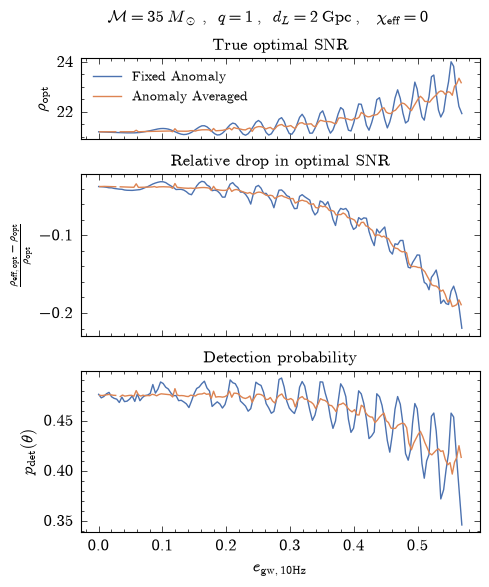

Figure saved as '../figures/selection_function.pdf'


In [4]:
# 3-panel figure: optimal SNR, relative SNR drop, p_det vs e_gw
E_GW_MAX = 0.57   # SEOBNRv5EHM dies past here at this mass
NUM_BINS = 160

mask = sweep["e_gw"] < E_GW_MAX
d = sweep.loc[mask].copy()
d["e_gw_bin"] = pd.cut(d["e_gw"], bins=NUM_BINS)
binned = d.groupby("e_gw_bin", observed=False)[
    ["rho_opt_cross", "rho_eff_opt_cross", "p_det"]
].mean()
centers = binned.index.categories.mid

fixed = sweep[(sweep["mean_anomaly"] == 0.0) & mask].sort_values("e_gw")

frac_binned = (binned["rho_eff_opt_cross"] - binned["rho_opt_cross"]) / binned["rho_opt_cross"]
frac_fixed = (fixed["rho_eff_opt_cross"] - fixed["rho_opt_cross"]) / fixed["rho_opt_cross"]

fig, axes = plt.subplots(3, 1, figsize=(5, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2, 2]})
axes[0].set_title("True optimal SNR")
axes[0].plot(fixed["e_gw"], fixed["rho_opt_cross"], label="Fixed Anomaly", color=COLORS["blue"])
axes[0].plot(centers, binned["rho_opt_cross"], label="Anomaly Averaged", color=COLORS["orange"])

axes[1].set_title("Relative drop in optimal SNR")
axes[1].plot(fixed["e_gw"], frac_fixed, color=COLORS["blue"])
axes[1].plot(centers, frac_binned, color=COLORS["orange"])

axes[2].set_title("Detection probability")
axes[2].plot(fixed["e_gw"], fixed["p_det"], color=COLORS["blue"])
axes[2].plot(centers, binned["p_det"], color=COLORS["orange"])

axes[0].legend(loc="upper left")
axes[0].set_ylabel(r"$\rho_{\mathrm{opt}}$")
axes[1].set_ylabel(r"$\frac{\rho_{\mathrm{eff, opt}} - \rho_{\mathrm{opt}}}{\rho_{\mathrm{opt}}}$")
axes[2].set_ylabel(r"$p_{\mathrm{det}}(\theta)$")
axes[2].set_xlabel(r"$e_{\mathrm{gw, 10Hz}}$")

dl_mpc = float(attrs.get("luminosity_distance_Mpc", 800.0))
dl_str = r"%g \: \mathrm{Gpc}" % (dl_mpc / 1000.0) if dl_mpc >= 1000 else r"%g \: \mathrm{Mpc}" % dl_mpc
fig.suptitle(r"$\mathcal{M} = 35 \: M_\odot \:$,  $q= 1 \:$,  $d_L = %s \:$,   $\chi_{\mathrm{eff}} = 0 \:$" % dl_str,
             x=0.55, y=0.97, ha="center")
plt.tight_layout()
fig.savefig("../figures/selection_function.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure saved as '../figures/selection_function.pdf'")
